# Validation of mean velocity values

In [1]:
from pathlib import Path
import pyarrow.parquet as pq
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import shapely
import builtins
import re

## Define datasets to compare

In [2]:
# actual data directories

augmenterra_data_dir = Path("/home/lukas/projects/ADUCAT/data/Augmenterra/processed")
own_insar_data_dir = Path("/home/lukas/projects/ADUCAT/data/final_outputs")
egms_data_dir = Path("/home/lukas/projects/ADUCAT/data/EGMS/vienna/processed")


print("Reference data directory:", augmenterra_data_dir)
print("Directly of own processed data:", own_insar_data_dir)
print("EGMS data directory:", egms_data_dir)


Reference data directory: /home/lukas/projects/ADUCAT/data/Augmenterra/processed
Directly of own processed data: /home/lukas/projects/ADUCAT/data/final_outputs
EGMS data directory: /home/lukas/projects/ADUCAT/data/EGMS/vienna/processed


In [3]:
orbit_direction = "ASC"
orbit = "073"

# actual data sets
ref_augmenterra_file = Path(augmenterra_data_dir, f"VIENNA_TUNNELLING_velocity_{orbit_direction}.parquet")
print("Augmenterra reference data file:", ref_augmenterra_file)

ref_egms_file = Path(egms_data_dir, f"EGMS_{orbit}_2020_2024.parquet")
print("EGMS reference data file:", ref_egms_file)

processed_data_file = Path(own_insar_data_dir, "download-isce2-new-xc6vs_result2.parquet")
print("Own processed data file:", processed_data_file)

# Vienna city boundary file
aoi_city_file = Path("/home/lukas/projects/ADUCAT/data/AOI/Projektgebiet_ADUCAT-AOI.gpkg")
print("AOI city file:", aoi_city_file)

Augmenterra reference data file: /home/lukas/projects/ADUCAT/data/Augmenterra/processed/VIENNA_TUNNELLING_velocity_ASC.parquet
EGMS reference data file: /home/lukas/projects/ADUCAT/data/EGMS/vienna/processed/EGMS_073_2020_2024.parquet
Own processed data file: /home/lukas/projects/ADUCAT/data/final_outputs/download-isce2-new-xc6vs_result2.parquet
AOI city file: /home/lukas/projects/ADUCAT/data/AOI/Projektgebiet_ADUCAT-AOI.gpkg


In [4]:
aoi_city = gpd.read_file(aoi_city_file)
aoi_polygon = aoi_city.to_crs("EPSG:4326").geometry.iloc[0]

print("AOI city geometry:", aoi_polygon)
print(type(aoi_polygon))

AOI city geometry: MULTIPOLYGON (((16.45342772507055 48.29727414692325, 16.453432875672 48.299522411683824, 16.4534380269105 48.30177067556145, 16.45344317878614 48.304018938556176, 16.45344833129904 48.306267200668046, 16.453453484449287 48.308515461896974, 16.453458638236974 48.310763722243045, 16.45346379266221 48.31301198170626, 16.453468947725085 48.3152602402866, 16.453474103425716 48.31750849798409, 16.45347925976419 48.31975675479874, 16.453484416740615 48.32200501073056, 16.453489574355075 48.32425326577953, 16.45011834885512 48.32425665617854, 16.446747122735218 48.324259947770585, 16.44337589601355 48.324263140555644, 16.440004668708333 48.324266234533674, 16.43663344083776 48.32426922970462, 16.433262212420026 48.32427212606847, 16.429890983473335 48.32427492362516, 16.426519754015885 48.32427762237466, 16.42314852406587 48.324280222316936, 16.419777293641495 48.32428272345196, 16.416406062760952 48.32428512577967, 16.41303483144244 48.32428742930005, 16.409663599704167 48.

### Data loading function 

In [40]:
def extract_points_in_polygon(
    parquet_file,
    polygon,
    polygon_crs="EPSG:4326",
    columns=None,
    data_crs="EPSG:4326"
):

    parquet = pq.ParquetFile(parquet_file)

    n_groups = parquet.num_row_groups

    print(f"Rows:       {parquet.metadata.num_rows:,}")
    print(f"Row groups: {n_groups}")
    print()

    # --------------------------------------------------------
    # Transform polygon to the CRS of the Parquet data
    # --------------------------------------------------------

    if polygon_crs != data_crs:

        polygon_gdf = gpd.GeoDataFrame(
            geometry=[polygon],
            crs=polygon_crs
        )

        polygon = polygon_gdf.to_crs(data_crs).geometry.iloc[0]

    # --------------------------------------------------------
    # Select columns
    # --------------------------------------------------------

    if columns is not None:

        columns = list(columns)

        if "geometry" not in columns:
            columns.append("geometry")

    results = []

    # --------------------------------------------------------
    # Process row groups
    # --------------------------------------------------------

    for i in builtins.range(n_groups):

        table = parquet.read_row_group(
            i,
            columns=columns
        )

        df = table.to_pandas()

        # WKB -> Shapely
        geometry = shapely.from_wkb(
            df["geometry"].to_numpy()
        )

        # Spatial filter
        mask = shapely.intersects(
            geometry,
            polygon
        )

        n_matches = int(mask.sum())

        if n_matches > 0:

            matched = df.loc[mask].copy()
            matched["geometry"] = geometry[mask]

            results.append(matched)

        print(
            f"Row group {i + 1:3d}/{n_groups}: "
            f"{n_matches:,} points inside"
        )

    # --------------------------------------------------------
    # Combine results
    # --------------------------------------------------------

    if results:

        result = pd.concat(
            results,
            ignore_index=True
        )

        return gpd.GeoDataFrame(
            result,
            geometry="geometry",
            crs=data_crs
        )

    # No points found
    return gpd.GeoDataFrame(
        columns=columns if columns is not None else parquet.schema.names,
        geometry="geometry",
        crs=data_crs
    )

## Statistics of the two data sets

### Augmenterra data

In [23]:
# ============================================================
# 1. Inspect column names
# ============================================================

print("\n" + "=" * 70)
print("AUGMENTERRA DATASET")
print("=" * 70)

augmenterra_columns = pd.read_parquet(
    ref_augmenterra_file,
    engine="pyarrow"
).columns.tolist()

for i, col in enumerate(augmenterra_columns):
    print(f"{i:3d}: {col}")


AUGMENTERRA DATASET
  0: CODE
  1: HEIGHT
  2: H_STDEV
  3: VEL
  4: V_STDEV
  5: ACC
  6: A_STDEV
  7: SEASON_AMP
  8: S_AMP_STD
  9: SEASON_PHS
 10: S_PHS_STD
 11: COHERENCE
 12: STD_DEF
 13: EFF_AREA
 14: INC_ANG
 15: D20190105
 16: D20190111
 17: D20190117
 18: D20190123
 19: D20190204
 20: D20190210
 21: D20190216
 22: D20190222
 23: D20190228
 24: D20190306
 25: D20190312
 26: D20190318
 27: D20190324
 28: D20190330
 29: D20190405
 30: D20190411
 31: D20190417
 32: D20190423
 33: D20190429
 34: D20190505
 35: D20190511
 36: D20190517
 37: D20190523
 38: D20190529
 39: D20190604
 40: D20190610
 41: D20190616
 42: D20190622
 43: D20190628
 44: D20190704
 45: D20190710
 46: D20190716
 47: D20190722
 48: D20190728
 49: D20190803
 50: D20190809
 51: D20190815
 52: D20190821
 53: D20190827
 54: D20190902
 55: D20190908
 56: D20190914
 57: D20190920
 58: D20190926
 59: D20191002
 60: D20191008
 61: D20191014
 62: D20191020
 63: D20191026
 64: D20191101
 65: D20191107
 66: D20191113
 67

In [24]:
# ============================================================
# Columns to load
# ============================================================

AUGMENTERRA_VELOCITY_COL = "VEL_20220101_20241231"
AUGMENTERRA_COHERENCE_COL = "COHERENCE"
AUGMENTERRA_GEOMETRY_COL = "geometry"

augmenterra_cols = [
    AUGMENTERRA_VELOCITY_COL,
    AUGMENTERRA_COHERENCE_COL,
    AUGMENTERRA_GEOMETRY_COL
]

In [25]:
augmenterra = gpd.read_parquet(
    ref_augmenterra_file,
    columns=augmenterra_cols
)

print(augmenterra.head())

print(augmenterra.crs, augmenterra.geometry.geom_type.value_counts().head())

   VEL_20220101_20241231  COHERENCE                   geometry
0                   -0.1       0.30  POINT (16.54783 48.13205)
1                    0.9       0.40  POINT (16.54763 48.13202)
2                   -0.0       0.36  POINT (16.54775 48.13204)
3                   -1.3       0.24  POINT (16.54635 48.13199)
4                   -1.1       0.24   POINT (16.5465 48.13201)
{"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis":

In [26]:
print("\nLoaded data:")
print(f"Augmenterra: {len(augmenterra):,} points")


Loaded data:
Augmenterra: 2,924,926 points


In [27]:
# ============================================================
# Basic statistics
# ============================================================

print("\n" + "=" * 70)
print("AUGMENTERRA VELOCITY STATISTICS")
print("=" * 70)

print(
    augmenterra[AUGMENTERRA_VELOCITY_COL]
    .describe()
)


AUGMENTERRA VELOCITY STATISTICS
count    2.924926e+06
mean    -3.382984e-01
std      1.754409e+00
min     -2.530000e+01
25%     -1.000000e+00
50%     -2.000000e-01
75%      5.000000e-01
max      1.410000e+01
Name: VEL_20220101_20241231, dtype: float64


In [28]:
print("\n" + "=" * 70)
print("AUGMENTERRA COHERENCE STATISTICS")
print("=" * 70)

print(
    augmenterra[AUGMENTERRA_COHERENCE_COL]
    .describe()
)


AUGMENTERRA COHERENCE STATISTICS
count    2.924926e+06
mean     5.852312e-01
std      2.138453e-01
min      1.500000e-01
25%      4.000000e-01
50%      5.700000e-01
75%      7.700000e-01
max      1.000000e+00
Name: COHERENCE, dtype: float64


### EGMS dataset

In [41]:
print("\n" + "=" * 70)
print("EGMS DATASET")
print("=" * 70)

egms_columns = pd.read_parquet(
    ref_egms_file,
    engine="pyarrow"
).columns.tolist()

for i, col in enumerate(egms_columns):
    print(f"{i:3d}: {col}")


EGMS DATASET
  0: pid
  1: cluster_label
  2: mp_type
  3: easting
  4: northing
  5: height_ortho
  6: height_ellipse
  7: line
  8: pixel
  9: rmse_ts
 10: temporal_coherence
 11: amplitude_dispersion
 12: incidence_angle
 13: track_angle
 14: los_east
 15: los_north
 16: los_up
 17: mean_velocity
 18: mean_velocity_std
 19: acceleration
 20: acceleration_std
 21: seasonality
 22: seasonality_std
 23: VEL_20220101_20241231
 24: V_STDERR_20220101_20241231
 25: VEL_20200101_20241231
 26: V_STDERR_20200101_20241231
 27: 20200106
 28: 20200112
 29: 20200118
 30: 20200124
 31: 20200130
 32: 20200205
 33: 20200211
 34: 20200217
 35: 20200223
 36: 20200306
 37: 20200312
 38: 20200318
 39: 20200324
 40: 20200330
 41: 20200405
 42: 20200411
 43: 20200417
 44: 20200423
 45: 20200429
 46: 20200505
 47: 20200511
 48: 20200517
 49: 20200523
 50: 20200529
 51: 20200604
 52: 20200610
 53: 20200616
 54: 20200622
 55: 20200628
 56: 20200704
 57: 20200710
 58: 20200716
 59: 20200722
 60: 20200728
 61

In [42]:
# ============================================================
# Columns to load
# ============================================================

EGMS_VELOCITY_COL = "mean_velocity"
EGMS_COHERENCE_COL = "temporal_coherence"
EGMS_GEOMETRY_COL = "geometry"

egms_cols = [
    EGMS_VELOCITY_COL,
    EGMS_COHERENCE_COL,
    EGMS_GEOMETRY_COL
]

In [43]:
egms = extract_points_in_polygon(
    ref_egms_file,
    aoi_polygon,
    columns=egms_cols
)

print(egms.head())

Rows:       1,446,002
Row groups: 17

Row group   1/17: 52,229 points inside
Row group   2/17: 97,042 points inside
Row group   3/17: 95,710 points inside
Row group   4/17: 85,751 points inside
Row group   5/17: 58,183 points inside
Row group   6/17: 26,395 points inside
Row group   7/17: 99,242 points inside
Row group   8/17: 99,909 points inside
Row group   9/17: 99,931 points inside
Row group  10/17: 99,991 points inside
Row group  11/17: 99,214 points inside
Row group  12/17: 98,441 points inside
Row group  13/17: 99,392 points inside
Row group  14/17: 93,082 points inside
Row group  15/17: 9,210 points inside
Row group  16/17: 39,216 points inside
Row group  17/17: 0 points inside
   mean_velocity  temporal_coherence                   geometry
0           -0.5                0.87  POINT (16.41325 48.11748)
1           -0.9                0.87   POINT (16.41322 48.1175)
2           -0.5                0.96   POINT (16.41322 48.1175)
3            0.7                0.74  POINT (16.4

In [10]:
print("\nLoaded data:")
print(f"EGMS:    {len(egms):,} points")


Loaded data:
EGMS:    1,252,938 points


In [11]:
# ============================================================
# Basic statistics
# ============================================================


print("\n" + "=" * 70)
print("EGMS VELOCITY STATISTICS")
print("=" * 70)

print(
    egms[EGMS_VELOCITY_COL]
    .describe()
)


EGMS VELOCITY STATISTICS
count    1.252938e+06
mean    -3.352805e-01
std      1.020761e+00
min     -9.070000e+01
25%     -7.000000e-01
50%     -3.000000e-01
75%      1.000000e-01
max      2.860000e+01
Name: mean_velocity, dtype: float64


In [12]:
print("\n" + "=" * 70)
print("EGMS COHERENCE STATISTICS")
print("=" * 70)

print(
    egms[EGMS_COHERENCE_COL]
    .describe()
)


EGMS COHERENCE STATISTICS
count    1.252938e+06
mean     8.001779e-01
std      1.098078e-01
min      1.000000e-02
25%      7.200000e-01
50%      8.200000e-01
75%      8.900000e-01
max      9.800000e-01
Name: temporal_coherence, dtype: float64


### Own dataset

In [15]:
print("\n" + "=" * 70)
print("OWN INSAR DATASET")
print("=" * 70)

own_columns = pd.read_parquet(
    processed_data_file,
    engine="pyarrow"
).columns.tolist()

for i, col in enumerate(own_columns):
    print(f"{i:3d}: {col}")


OWN INSAR DATASET
  0: CODE
  1: HEIGHT
  2: H_STDEV
  3: VEL
  4: V_STDEV
  5: COHERENCE
  6: EFF_AREA
  7: D20220101
  8: D20220113
  9: D20220125
 10: D20220206
 11: D20220218
 12: D20220302
 13: D20220314
 14: D20220326
 15: D20220407
 16: D20220419
 17: D20220501
 18: D20220513
 19: D20220525
 20: D20220606
 21: D20220618
 22: D20220630
 23: D20220712
 24: D20220724
 25: D20220805
 26: D20220817
 27: D20220829
 28: D20220910
 29: D20220922
 30: D20221004
 31: D20221016
 32: D20221028
 33: D20221109
 34: D20221121
 35: D20221203
 36: D20221215
 37: D20221227
 38: D20230108
 39: D20230120
 40: D20230201
 41: D20230213
 42: D20230225
 43: D20230309
 44: D20230321
 45: D20230402
 46: D20230414
 47: D20230426
 48: D20230508
 49: D20230520
 50: D20230601
 51: D20230613
 52: D20230625
 53: D20230707
 54: D20230719
 55: D20230731
 56: D20230812
 57: D20230824
 58: D20230905
 59: D20230917
 60: D20230929
 61: D20231011
 62: D20231023
 63: D20231104
 64: D20231116
 65: D20231128
 66: D2023

In [16]:
# ============================================================
# Columns to load
# ============================================================

OWN_VELOCITY_COL = "VEL"
OWN_COHERENCE_COL = "COHERENCE"
OWN_GEOMETRY_COL = "geometry"

own_cols = [
    OWN_VELOCITY_COL,
    OWN_COHERENCE_COL,
    OWN_GEOMETRY_COL
]

In [17]:
own = extract_points_in_polygon(
    processed_data_file,
    aoi_polygon,
    columns=own_cols
)

print(own.head())

Rows:       670,071
Row groups: 21

Row group   1/21: 0 points inside
Row group   2/21: 0 points inside
Row group   3/21: 1,235 points inside
Row group   4/21: 20,724 points inside
Row group   5/21: 45,273 points inside
Row group   6/21: 47,117 points inside
Row group   7/21: 45,922 points inside
Row group   8/21: 42,016 points inside
Row group   9/21: 54,002 points inside
Row group  10/21: 57,067 points inside
Row group  11/21: 56,481 points inside
Row group  12/21: 50,224 points inside
Row group  13/21: 43,115 points inside
Row group  14/21: 35,088 points inside
Row group  15/21: 22,368 points inside
Row group  16/21: 16,365 points inside
Row group  17/21: 9,256 points inside
Row group  18/21: 8 points inside
Row group  19/21: 0 points inside
Row group  20/21: 0 points inside
Row group  21/21: 0 points inside
         VEL  COHERENCE                   geometry
0 -18.978948   0.926077  POINT (16.52671 48.13625)
1 -15.369507   0.906998  POINT (16.52123 48.13585)
2 -17.103702   0.941122 

In [18]:
print("\nLoaded data:")
print(f"Own SBAS:    {len(own):,} points")


Loaded data:
Own SBAS:    546,261 points


In [19]:
# ============================================================
# Basic statistics
# ============================================================


print("\n" + "=" * 70)
print("OWN SBAS VELOCITY STATISTICS")
print("=" * 70)

print(
    own[OWN_VELOCITY_COL]
    .describe()
)


OWN SBAS VELOCITY STATISTICS
count    546261.000000
mean         -0.524658
std           3.628272
min         -57.821102
25%          -1.795701
50%          -0.214161
75%           1.156176
max          45.415968
Name: VEL, dtype: float64


In [20]:
print("\n" + "=" * 70)
print("OWN SBAS COHERENCE STATISTICS")
print("=" * 70)

print(
    own[OWN_COHERENCE_COL]
    .describe()
)


OWN SBAS COHERENCE STATISTICS
count    546261.000000
mean          0.977270
std           0.029410
min           0.700419
25%           0.970618
50%           0.989281
75%           0.995741
max           1.000000
Name: COHERENCE, dtype: float64


## Comparison

### velocity histograms

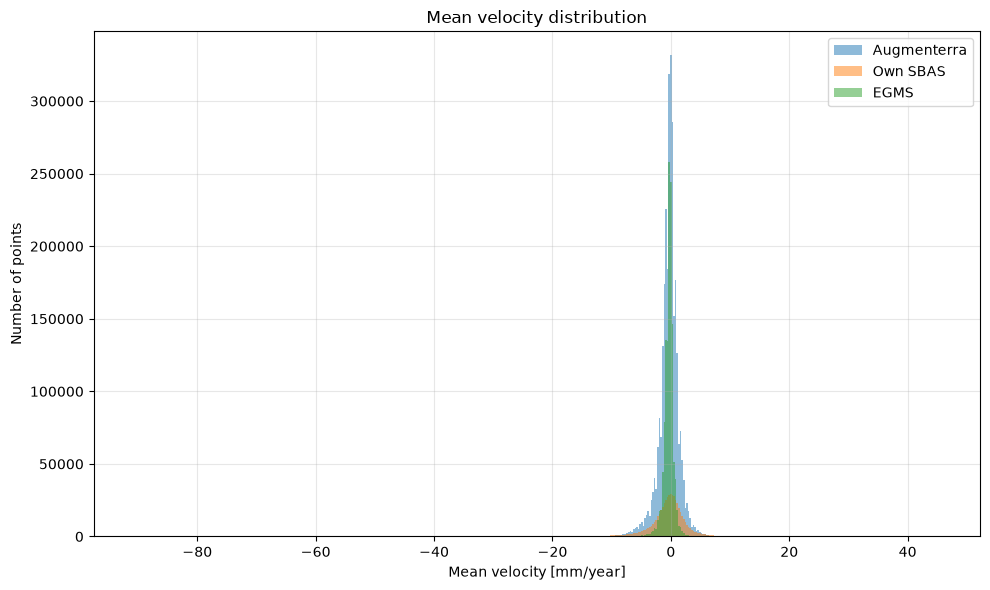

In [29]:
velocity_all = pd.concat([
    augmenterra[AUGMENTERRA_VELOCITY_COL],
    own[OWN_VELOCITY_COL],
    egms[EGMS_VELOCITY_COL]
]).dropna()

# Use common range
v_min = velocity_all.min()
v_max = velocity_all.max()

bins = np.linspace(v_min, v_max, 500)


plt.figure(figsize=(10, 6))

plt.hist(
    augmenterra[AUGMENTERRA_VELOCITY_COL].dropna(),
    bins=bins,
    alpha=0.5,
    label="Augmenterra",
)

plt.hist(
    own[OWN_VELOCITY_COL].dropna(),
    bins=bins,
    alpha=0.5,
    label="Own SBAS",
)

plt.hist(
    egms[EGMS_VELOCITY_COL].dropna(),
    bins=bins,
    alpha=0.5,
    label="EGMS",
)



plt.xlabel("Mean velocity [mm/year]")
plt.ylabel("Number of points")
plt.title("Mean velocity distribution")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

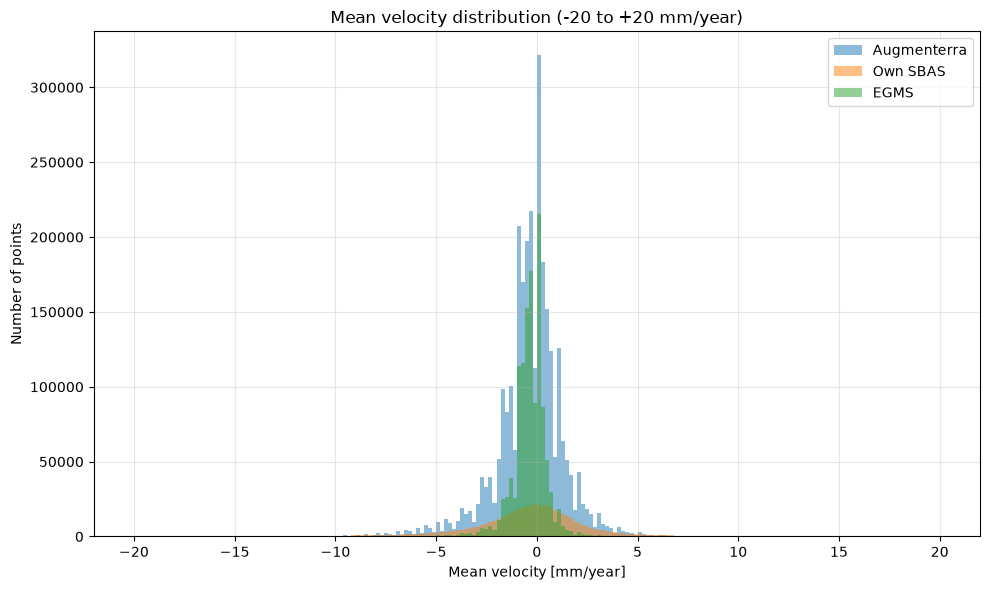

In [30]:
plt.figure(figsize=(10, 6))

range =(-20, 20)
bins= 200

plt.hist(
    augmenterra[AUGMENTERRA_VELOCITY_COL].dropna(),
    bins=bins,
    range=range,
    alpha=0.5,
    label="Augmenterra",
)

plt.hist(
    own[OWN_VELOCITY_COL].dropna(),
    bins=bins,
    range=range,
    alpha=0.5,
    label="Own SBAS",
)

plt.hist(
    egms[EGMS_VELOCITY_COL].dropna(),
    bins=bins,
    range=range,
    alpha=0.5,
    label="EGMS",
)

plt.xlabel("Mean velocity [mm/year]")
plt.ylabel("Number of points")
plt.title("Mean velocity distribution (-20 to +20 mm/year)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

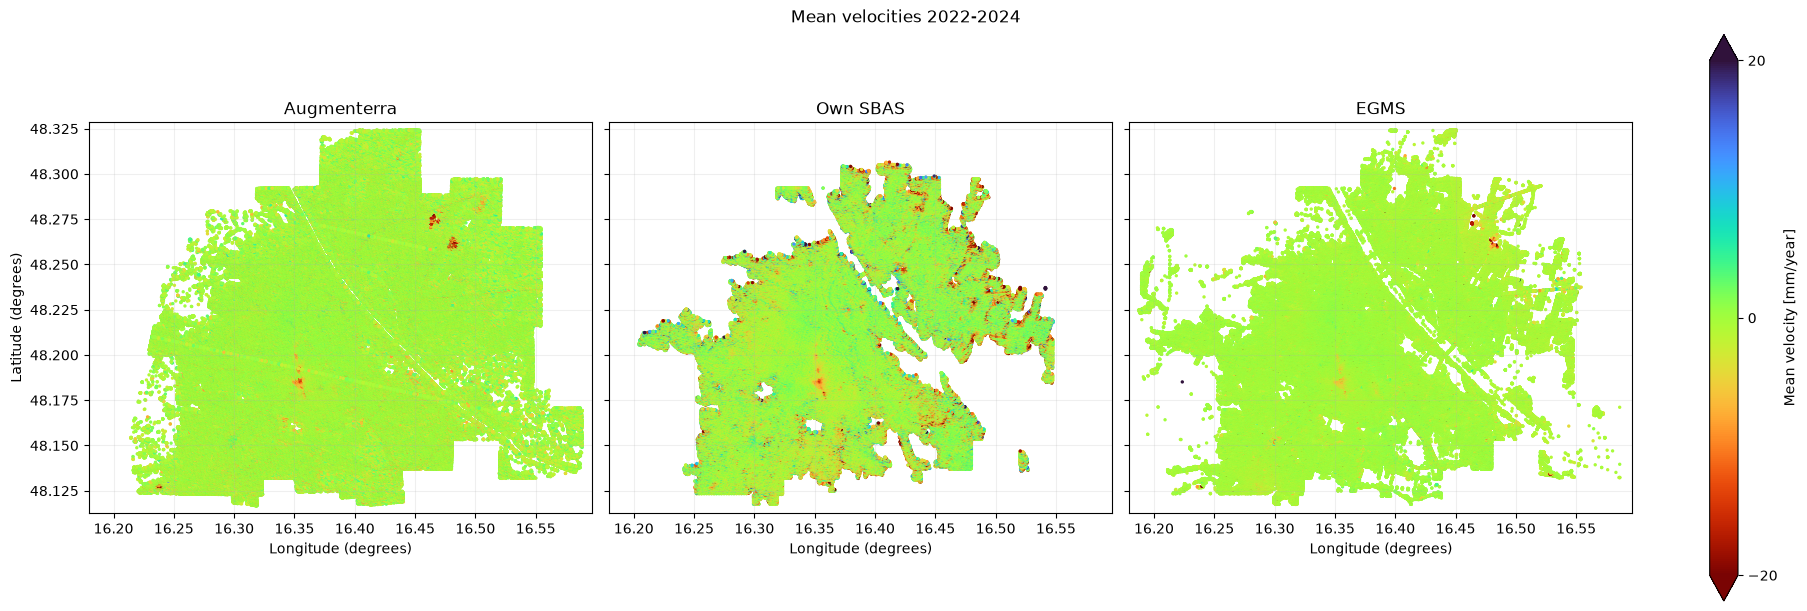

In [31]:
map_datasets = [
    ("Augmenterra", augmenterra, AUGMENTERRA_VELOCITY_COL),
    ("Own SBAS", own, OWN_VELOCITY_COL),
    ("EGMS", egms, EGMS_VELOCITY_COL),
]

target_crs = augmenterra.crs
if target_crs is None or any(frame.crs is None for _, frame, _ in map_datasets):
    raise ValueError("All datasets must have a defined CRS before plotting.")

map_data = []
for name, frame, velocity_col in map_datasets:
    data = frame[[velocity_col, frame.geometry.name]].dropna().copy()
    data = data.loc[np.isfinite(data[velocity_col].to_numpy())]
    if data.crs != target_crs:
        data = data.to_crs(target_crs)
    map_data.append((name, data, velocity_col))

velocity_vmin, velocity_vmax = -20, 20
bounds = np.vstack([data.total_bounds for _, data, _ in map_data])
x_min, y_min = bounds[:, :2].min(axis=0)
x_max, y_max = bounds[:, 2:].max(axis=0)
x_pad = (x_max - x_min) * 0.02
y_pad = (y_max - y_min) * 0.02

if target_crs.is_geographic:
    x_label, y_label = "Longitude (degrees)", "Latitude (degrees)"
else:
    x_label, y_label = "X coordinate", "Y coordinate"

fig, axes = plt.subplots(
    1, 3, figsize=(18, 6), sharex=True, sharey=True, constrained_layout=True
)
fig.suptitle("Mean velocities 2022-2024")
for axis, (name, data, velocity_col) in zip(axes, map_data):
    data.plot(
        ax=axis,
        column=velocity_col,
        markersize=2,
        cmap="turbo_r",
        vmin=velocity_vmin,
        vmax=velocity_vmax,
        legend=False,
        rasterized=True,
    )
    axis.set_title(name)
    axis.set_xlabel(x_label)
    axis.grid(alpha=0.2)

axes[0].set_ylabel(y_label)
for axis in axes:
    axis.set_xlim(x_min - x_pad, x_max + x_pad)
    axis.set_ylim(y_min - y_pad, y_max + y_pad)

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

color_mappable = ScalarMappable(
    norm=Normalize(vmin=velocity_vmin, vmax=velocity_vmax), cmap="turbo_r"
)
fig.colorbar(
    color_mappable,
    ax=axes,
    ticks=[velocity_vmin, 0, velocity_vmax],
    label="Mean velocity [mm/year]",
    extend="both",
)
plt.show()

## Comparison of mean velocities in a polygon

In [32]:
# polygon to evaluate

polygon_test = Path("/home/lukas/projects/ADUCAT/data/AOI/polygon_test.gpkg")
polygon_gdf = gpd.read_file(polygon_test)

In [33]:
polygon_gdf.head()

,id,geometry
0,1,"MULTIPOLYGON (((16.35336 48.18653, 16.35494 48..."
1,2,"MULTIPOLYGON (((16.36945 48.20945, 16.37013 48..."
2,3,"MULTIPOLYGON (((16.34723 48.18841, 16.34734 48..."


In [34]:
polygon_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [35]:
# choose a test polygon by index
test_polygon_index = 0
test_polygon = polygon_gdf.geometry.iloc[test_polygon_index]

print(f"Selected test polygon: {test_polygon}")

Selected test polygon: MULTIPOLYGON (((16.353360515719384 48.186530051127846, 16.354944131963418 48.187072301047984, 16.355903339208506 48.18621373867443, 16.353960276994687 48.18584196884283, 16.353360515719384 48.186530051127846)))


In [36]:
print(type(test_polygon))
print(test_polygon.bounds)

<class 'shapely.geometry.multipolygon.MultiPolygon'>
(16.353360515719384, 48.18584196884283, 16.355903339208506, 48.187072301047984)


### Read just points inside the polygon

**Read just the points within a certain polygon**

In [44]:
augmenterra_polygon = extract_points_in_polygon(
    ref_augmenterra_file,
    test_polygon
)

egms_polygon = extract_points_in_polygon(
    ref_egms_file,
    test_polygon
)

own_processed_polygon = extract_points_in_polygon(
    processed_data_file,
    test_polygon
)


Rows:       2,924,926
Row groups: 150

Row group   1/150: 0 points inside
Row group   2/150: 0 points inside
Row group   3/150: 0 points inside
Row group   4/150: 0 points inside
Row group   5/150: 0 points inside
Row group   6/150: 0 points inside
Row group   7/150: 0 points inside
Row group   8/150: 0 points inside
Row group   9/150: 0 points inside
Row group  10/150: 0 points inside
Row group  11/150: 0 points inside
Row group  12/150: 0 points inside
Row group  13/150: 0 points inside
Row group  14/150: 0 points inside
Row group  15/150: 0 points inside
Row group  16/150: 0 points inside
Row group  17/150: 0 points inside
Row group  18/150: 0 points inside
Row group  19/150: 0 points inside
Row group  20/150: 0 points inside
Row group  21/150: 0 points inside
Row group  22/150: 0 points inside
Row group  23/150: 0 points inside
Row group  24/150: 0 points inside
Row group  25/150: 0 points inside
Row group  26/150: 0 points inside
Row group  27/150: 0 points inside
Row group  28/15

### Plot the points that are located inside the polygons

In [45]:
marker_size = 30

vmin = -30
vmax = 30
print(f"Velocity range for plotting: {vmin:.2f} to {vmax:.2f} mm/year")

Velocity range for plotting: -30.00 to 30.00 mm/year


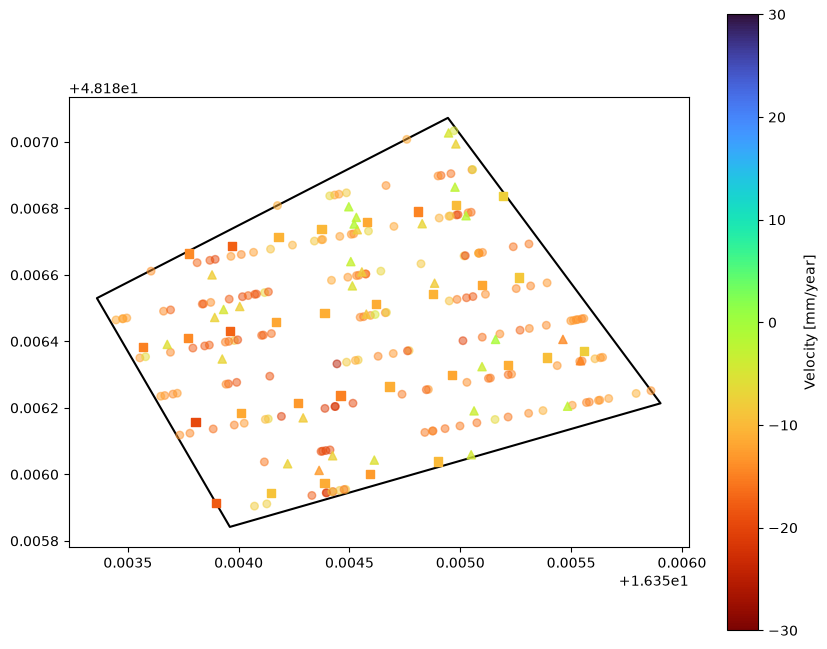

In [46]:
fig, ax = plt.subplots(figsize=(10, 10))

gpd.GeoSeries(
    [test_polygon],
    crs=polygon_gdf.crs
).plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.5
)

augmenterra_polygon.plot(
    ax=ax,
    column="VEL_20220101_20241231",
    cmap="turbo_r",
    vmin=vmin,
    vmax=vmax,
    markersize=marker_size,
    marker="o",
    legend=True,
    legend_kwds={
        "label": "Velocity [mm/year]",
        "shrink": 0.8
    },
    alpha=0.5,
)

egms_polygon.plot(
    ax=ax,
    column="VEL_20220101_20241231",
    cmap="turbo_r",
    vmin=vmin,
    vmax=vmax,
    markersize=marker_size +5,
    marker="^",
    alpha=0.8,
)


own_processed_polygon.plot(
    ax=ax,
    column="VEL",
    cmap="turbo_r",
    vmin=vmin,
    vmax=vmax,
    markersize=marker_size +5,
    marker="s",
)

plt.show()

### Calculate statistics of the velocities

In [47]:
stats = pd.DataFrame({
    "Augmenterra": augmenterra_polygon["VEL_20220101_20241231"].describe(),
    "EGMS": egms_polygon["VEL_20220101_20241231"].describe(),
    "Own processing": own_processed_polygon["VEL"].describe()
})

stats

,Augmenterra,EGMS,Own processing
count,183.000000,32.000000,31.000000
mean,-14.086885,-6.100000,-12.231032
std,3.757080,3.441493,2.995042
min,-25.300000,-14.600000,-19.602723
25%,-16.700000,-7.825000,-14.172036
50%,-14.100000,-6.300000,-11.488657
75%,-12.150000,-3.550000,-10.386960
max,-4.600000,-0.700000,-7.628668


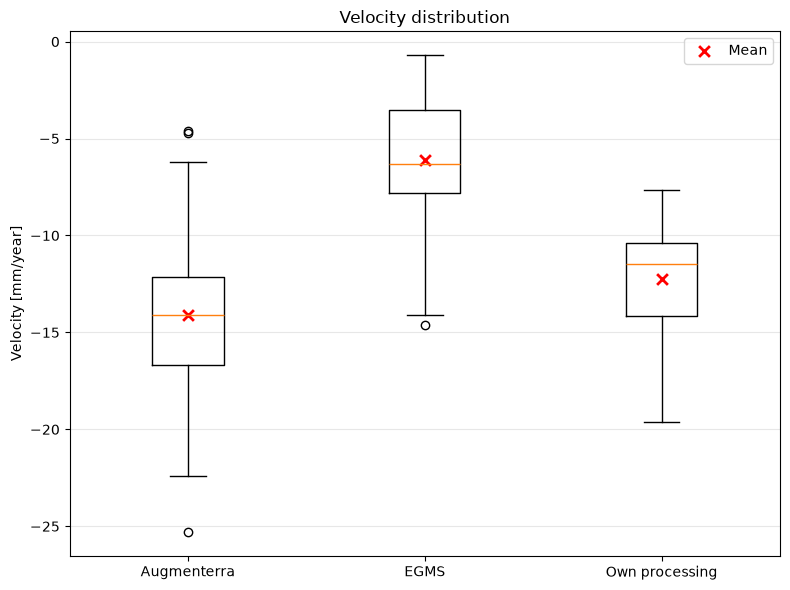

In [49]:
velocities = [
    augmenterra_polygon["VEL_20220101_20241231"].dropna(),
    egms_polygon["VEL_20220101_20241231"].dropna(),
    own_processed_polygon["VEL"].dropna()
]

labels = [
    "Augmenterra",
    "EGMS",
    "Own processing"
]

fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(
    velocities,
    tick_labels=labels,
    showfliers=True
)

# Add mean values
means = [v.mean() for v in velocities]

ax.scatter(
    builtins.range(1, len(means) + 1),
    means,
    marker="x",
    color="red",
    s=60,
    linewidths=2,
    label="Mean"
)

ax.set_ylabel("Velocity [mm/year]")
ax.set_title("Velocity distribution")
ax.grid(axis="y", alpha=0.3)

ax.legend()

plt.tight_layout()
plt.show()

### Time series analysis of that polygon

In [50]:
# ============================================================
# Time range to plot
# ============================================================

start_date = pd.Timestamp("2019-01-01")
end_date   = pd.Timestamp("2026-04-30")


In [51]:
# ============================================================
# Find Augmenterra time-series columns within the selected time range
# ============================================================

ts_columns = []

for col in augmenterra_polygon.columns:
    if re.fullmatch(r"D\d{8}", col):
        date = pd.to_datetime(col[1:], format="%Y%m%d")

        if start_date <= date <= end_date:
            ts_columns.append(col)

# Convert column names to datetime
dates = pd.to_datetime(
    [col[1:] for col in ts_columns],
    format="%Y%m%d"
)

print(f"Number of points:     {len(augmenterra_polygon):,}")
print(f"Number of time steps: {len(ts_columns)}")
print(f"First date:           {dates.min().date()}")
print(f"Last date:            {dates.max().date()}")

Number of points:     183
Number of time steps: 343
First date:           2019-01-05
Last date:            2026-04-28


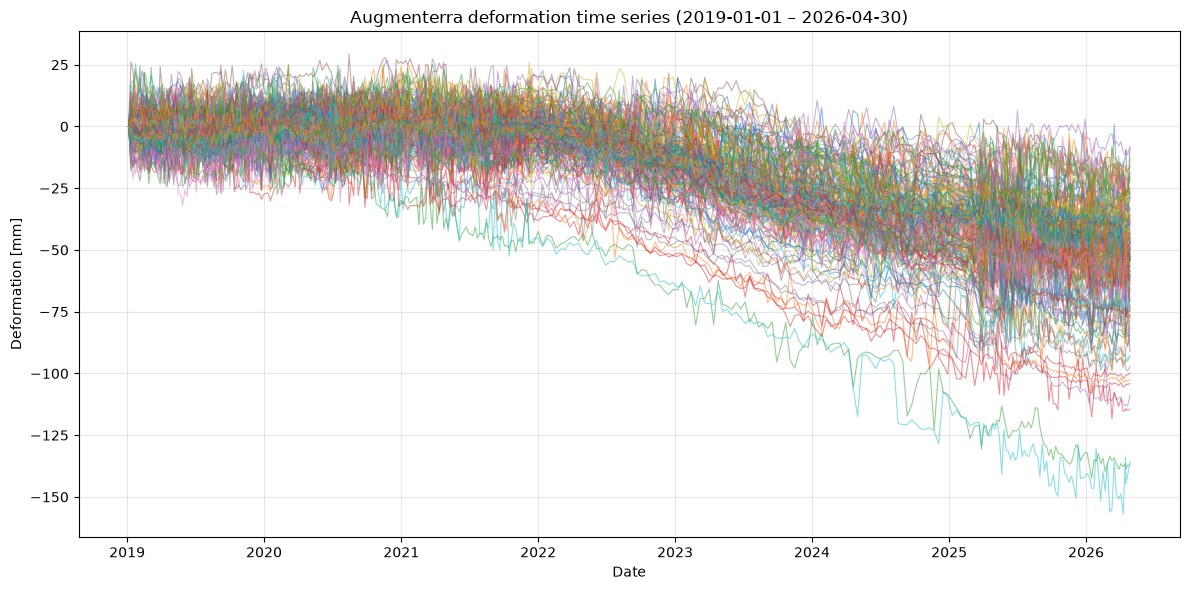

In [52]:
# ============================================================
# Plot time series
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

for _, row in augmenterra_polygon.iterrows():

    ax.plot(
        dates,
        row[ts_columns],
        linewidth=0.8,
        alpha=0.5
    )

ax.set_xlabel("Date")
ax.set_ylabel("Deformation [mm]")
ax.set_title(
    f"Augmenterra deformation time series "
    f"({start_date.date()} – {end_date.date()})"
)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
# ============================================================
# Find EGMS time-series columns within the selected time range
# ============================================================

ts_columns = []

for col in egms_polygon.columns:

    if re.fullmatch(r"\d{8}", str(col)):

        date = pd.to_datetime(str(col), format="%Y%m%d")

        if start_date <= date <= end_date:
            ts_columns.append(col)

# Convert column names to datetime
dates = pd.to_datetime(
    [str(col) for col in ts_columns],
    format="%Y%m%d"
)

print(f"Number of points:     {len(egms_polygon):,}")
print(f"Number of time steps: {len(ts_columns)}")
print(f"First date:           {dates.min().date()}")
print(f"Last date:            {dates.max().date()}")

Number of points:     32
Number of time steps: 209
First date:           2020-01-06
Last date:            2024-12-28


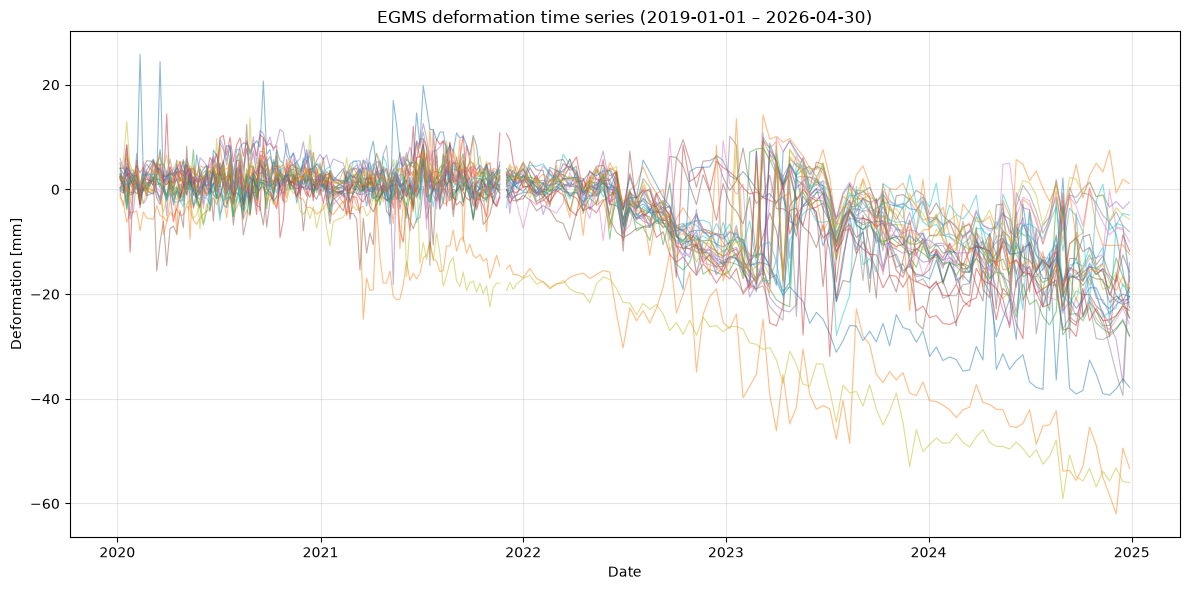

In [54]:
# ============================================================
# Plot time series
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

for _, row in egms_polygon.iterrows():

    ax.plot(
        dates,
        row[ts_columns],
        linewidth=0.8,
        alpha=0.5
    )

ax.set_xlabel("Date")
ax.set_ylabel("Deformation [mm]")
ax.set_title(
    f"EGMS deformation time series "
    f"({start_date.date()} – {end_date.date()})"
)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Number of points:     31
Number of time steps: 92
First date:           2022-01-01
Last date:            2024-12-28


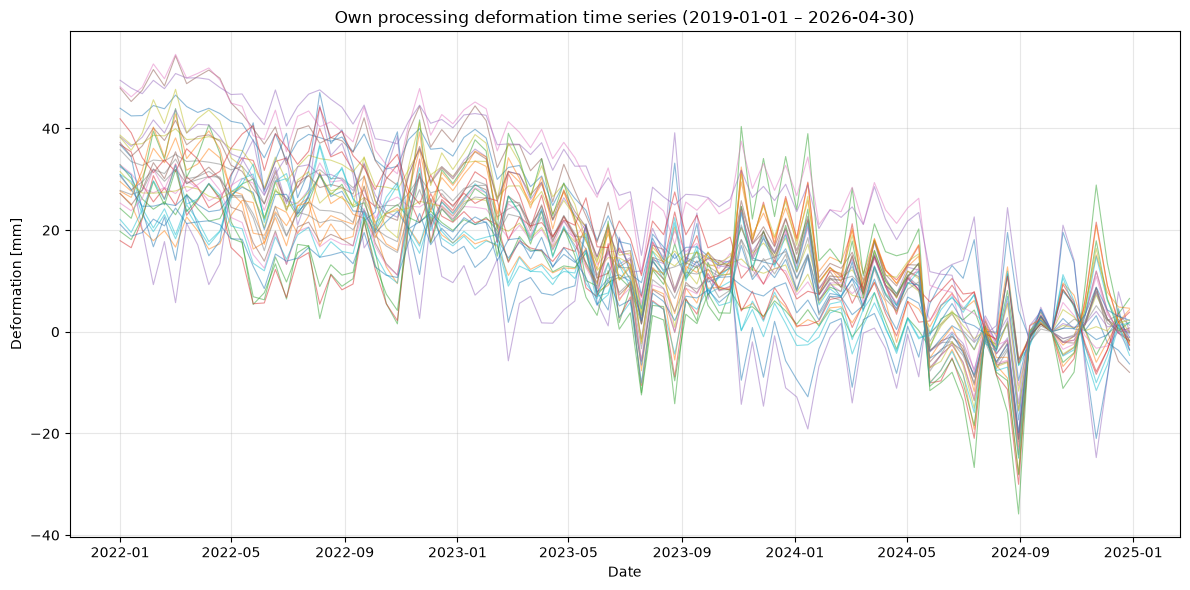

In [55]:
# ============================================================
# Find own processed time-series columns within the selected time range
# ============================================================

ts_columns = []

for col in own_processed_polygon.columns:

    if re.fullmatch(r"D\d{8}", col):

        date = pd.to_datetime(col[1:], format="%Y%m%d")

        if start_date <= date <= end_date:
            ts_columns.append(col)

# Convert column names to datetime
dates = pd.to_datetime(
    [col[1:] for col in ts_columns],
    format="%Y%m%d"
)

print(f"Number of points:     {len(own_processed_polygon):,}")
print(f"Number of time steps: {len(ts_columns)}")
print(f"First date:           {dates.min().date()}")
print(f"Last date:            {dates.max().date()}")


# ============================================================
# Plot time series
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

for _, row in own_processed_polygon.iterrows():

    ax.plot(
        dates,
        row[ts_columns],
        linewidth=0.8,
        alpha=0.5
    )

ax.set_xlabel("Date")
ax.set_ylabel("Deformation [mm]")
ax.set_title(
    f"Own processing deformation time series "
    f"({start_date.date()} – {end_date.date()})"
)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

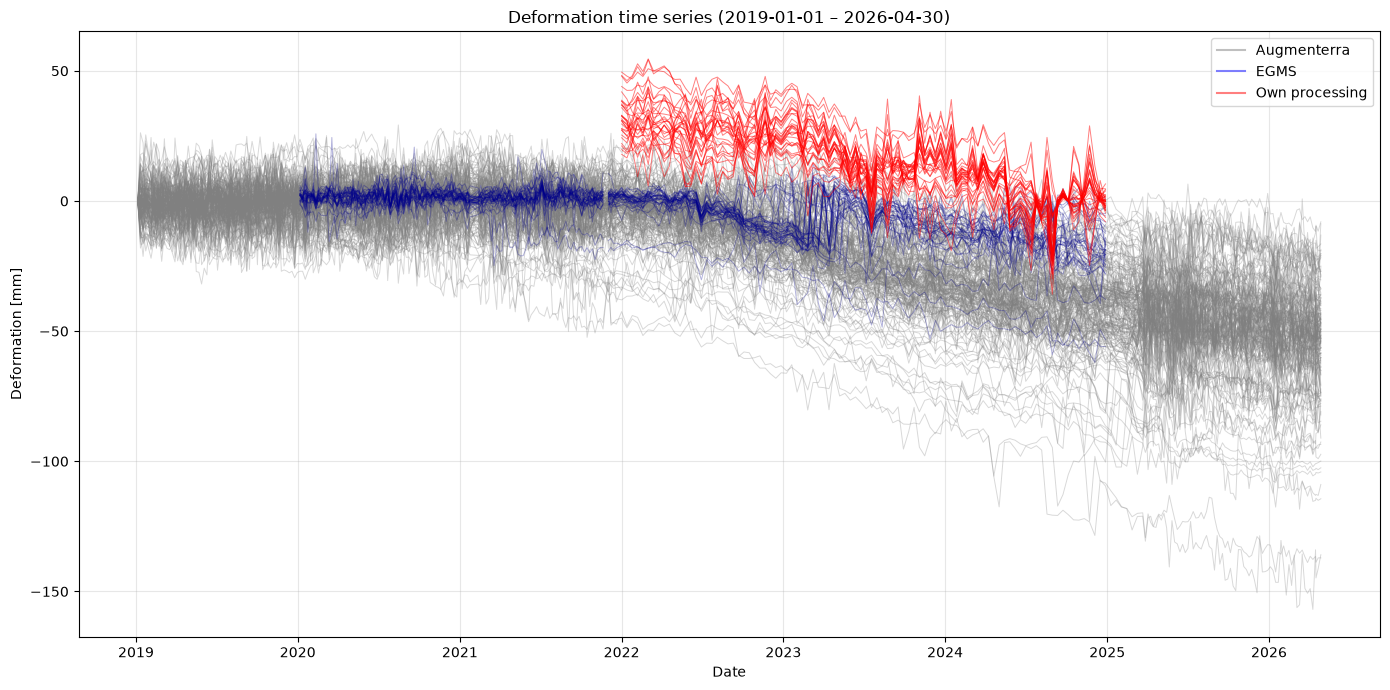

In [56]:
# ============================================================
# Helper to get time-series columns
# ============================================================

def get_ts_columns(gdf, prefix="D"):

    columns = []

    for col in gdf.columns:

        if prefix == "D":
            match = re.fullmatch(r"D\d{8}", str(col))
            date_string = str(col)[1:]

        else:
            match = re.fullmatch(r"\d{8}", str(col))
            date_string = str(col)

        if match:
            date = pd.to_datetime(date_string, format="%Y%m%d")

            if start_date <= date <= end_date:
                columns.append(col)

    dates = pd.to_datetime(
        [str(col)[1:] if prefix == "D" else str(col)
         for col in columns],
        format="%Y%m%d"
    )

    return columns, dates


# ============================================================
# Get time-series columns
# ============================================================

aug_columns, aug_dates = get_ts_columns(
    augmenterra_polygon,
    prefix="D"
)

egms_columns, egms_dates = get_ts_columns(
    egms_polygon,
    prefix=""
)

own_columns, own_dates = get_ts_columns(
    own_processed_polygon,
    prefix="D"
)


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))


# Augmenterra — gray
for _, row in augmenterra_polygon.iterrows():

    ax.plot(
        aug_dates,
        row[aug_columns],
        color="gray",
        alpha=0.3,
        linewidth=0.7
    )


# EGMS — blue
for _, row in egms_polygon.iterrows():

    ax.plot(
        egms_dates,
        row[egms_columns],
        color="darkblue",
        alpha=0.3,
        linewidth=0.7
    )


# Own processing — red
for _, row in own_processed_polygon.iterrows():

    ax.plot(
        own_dates,
        row[own_columns],
        color="red",
        alpha=0.5,
        linewidth=0.7
    )


# ============================================================
# Formatting
# ============================================================

ax.set_xlabel("Date")
ax.set_ylabel("Deformation [mm]")

ax.set_title(
    f"Deformation time series "
    f"({start_date.date()} – {end_date.date()})"
)

ax.grid(True, alpha=0.3)

# Legend using dummy lines
ax.plot([], [], color="gray", alpha=0.5, label="Augmenterra")
ax.plot([], [], color="blue", alpha=0.5, label="EGMS")
ax.plot([], [], color="red", alpha=0.5, label="Own processing")

ax.legend()

plt.tight_layout()
plt.show()

### Check the reference dates and align time series to a common reference date

**Augmenterra**

In [57]:
print(augmenterra_polygon["D20190105"].describe())

count    183.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: D20190105, dtype: float64


Reference date for Augmenterra is the 2019-01-05 (first date of the analysis)

**EGMS**

EGMS uses a virtual temporal reference based on a model of the time series.

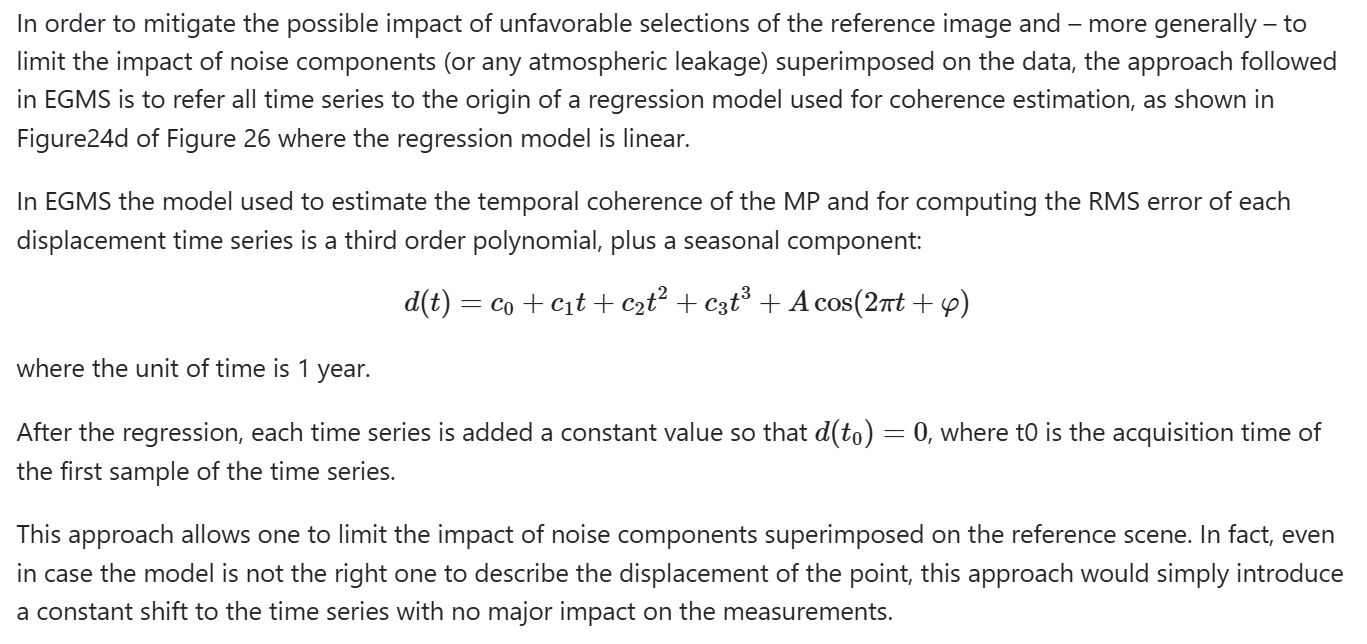

**Own processed data**

In [58]:
zero_dates = []

for col in own_processed_polygon.columns:

    if re.fullmatch(r"D\d{8}", str(col)):

        values = pd.to_numeric(
            own_processed_polygon[col],
            errors="coerce"
        )

        if np.isclose(values.dropna(), 0, atol=1e-6).all():
            zero_dates.append(col)

print(zero_dates)

['D20241005']


In [59]:
print(own_processed_polygon["D20241005"].describe())

count    31.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: D20241005, dtype: float64


Re-reference time series to a common reference date

In [60]:
import re
import pandas as pd

def get_ts_dates(gdf, prefix="D"):
    
    if prefix == "D":
        columns = [
            col for col in gdf.columns
            if re.fullmatch(r"D\d{8}", str(col))
        ]
        dates = pd.to_datetime(
            [str(col)[1:] for col in columns],
            format="%Y%m%d"
        )
    else:
        columns = [
            col for col in gdf.columns
            if re.fullmatch(r"\d{8}", str(col))
        ]
        dates = pd.to_datetime(
            [str(col) for col in columns],
            format="%Y%m%d"
        )
    
    return sorted(dates)

In [61]:
aug_dates = get_ts_dates(augmenterra_polygon, prefix="D")
egms_dates = get_ts_dates(egms_polygon, prefix="")
own_dates = get_ts_dates(own_processed_polygon, prefix="D")

print("Augmenterra:")
print(aug_dates[0], "→", aug_dates[-1])

print("\nEGMS:")
print(egms_dates[0], "→", egms_dates[-1])

print("\nOwn:")
print(own_dates[0], "→", own_dates[-1])

Augmenterra:
2019-01-05 00:00:00 → 2026-04-28 00:00:00

EGMS:
2020-01-06 00:00:00 → 2024-12-28 00:00:00

Own:
2022-01-01 00:00:00 → 2024-12-28 00:00:00


In [62]:
common_dates = sorted(
    set(aug_dates)
    & set(egms_dates)
    & set(own_dates)
)

print(f"\nCommon acquisition dates: {len(common_dates)}")
print(common_dates)


Common acquisition dates: 92
[Timestamp('2022-01-01 00:00:00'), Timestamp('2022-01-13 00:00:00'), Timestamp('2022-01-25 00:00:00'), Timestamp('2022-02-06 00:00:00'), Timestamp('2022-02-18 00:00:00'), Timestamp('2022-03-02 00:00:00'), Timestamp('2022-03-14 00:00:00'), Timestamp('2022-03-26 00:00:00'), Timestamp('2022-04-07 00:00:00'), Timestamp('2022-04-19 00:00:00'), Timestamp('2022-05-01 00:00:00'), Timestamp('2022-05-13 00:00:00'), Timestamp('2022-05-25 00:00:00'), Timestamp('2022-06-06 00:00:00'), Timestamp('2022-06-18 00:00:00'), Timestamp('2022-06-30 00:00:00'), Timestamp('2022-07-12 00:00:00'), Timestamp('2022-07-24 00:00:00'), Timestamp('2022-08-05 00:00:00'), Timestamp('2022-08-17 00:00:00'), Timestamp('2022-08-29 00:00:00'), Timestamp('2022-09-10 00:00:00'), Timestamp('2022-09-22 00:00:00'), Timestamp('2022-10-04 00:00:00'), Timestamp('2022-10-16 00:00:00'), Timestamp('2022-10-28 00:00:00'), Timestamp('2022-11-09 00:00:00'), Timestamp('2022-11-21 00:00:00'), Timestamp('2022-1

In [63]:
print("First common acquisition:", common_dates[0])

First common acquisition: 2022-01-01 00:00:00


In [64]:
reference_date = common_dates[0]

In [65]:
def rereference_timeseries(gdf, prefix="D"):

    # Find time-series columns
    if prefix == "D":
        ts_columns = [
            col for col in gdf.columns
            if re.fullmatch(r"D\d{8}", str(col))
        ]
    else:
        ts_columns = [
            col for col in gdf.columns
            if re.fullmatch(r"\d{8}", str(col))
        ]

    # Sort chronologically
    ts_columns = sorted(
        ts_columns,
        key=lambda x: pd.to_datetime(
            str(x)[1:] if prefix == "D" else str(x),
            format="%Y%m%d"
        )
    )

    # Column corresponding to reference_date
    if prefix == "D":
        reference_column = "D" + reference_date.strftime("%Y%m%d")
    else:
        reference_column = reference_date.strftime("%Y%m%d")

    if reference_column not in gdf.columns:
        raise ValueError(
            f"Reference column {reference_column} not found."
        )

    # Reference value for every point
    reference_values = pd.to_numeric(
        gdf[reference_column],
        errors="coerce"
    ).to_numpy(dtype=float)

    # Extract time-series values
    values = gdf[ts_columns].apply(
        pd.to_numeric,
        errors="coerce"
    ).to_numpy(dtype=float)

    # Subtract each point's value at the reference date
    rereferenced_values = values - reference_values[:, None]

    # Copy original GeoDataFrame
    result = gdf.copy()

    # Replace time-series values
    result[ts_columns] = rereferenced_values

    return result, reference_values

In [66]:
augmenterra_reref, aug_ref_values = rereference_timeseries(
    augmenterra_polygon,
    prefix="D"
)

egms_reref, egms_ref_values = rereference_timeseries(
    egms_polygon,
    prefix=""
)

own_reref, own_ref_values = rereference_timeseries(
    own_processed_polygon,
    prefix="D"
)

In [67]:
print(augmenterra_reref["D20220101"].describe())
print(egms_reref["20220101"].describe())
print(own_reref["D20220101"].describe())

count    183.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: D20220101, dtype: float64
count    32.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: 20220101, dtype: float64
count    31.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: D20220101, dtype: float64


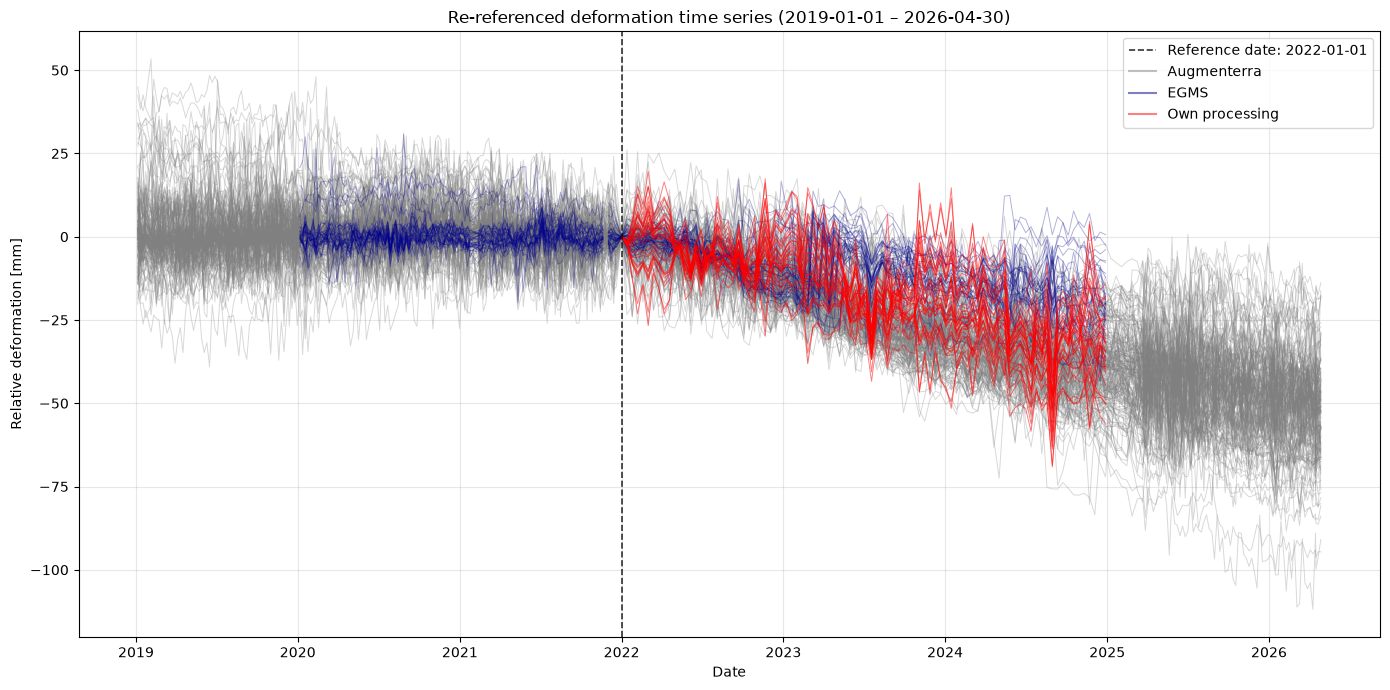

In [68]:
# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))


# Augmenterra — gray
for _, row in augmenterra_reref.iterrows():

    ax.plot(
        aug_dates,
        row[aug_columns],
        color="gray",
        alpha=0.3,
        linewidth=0.7
    )


# EGMS — dark blue
for _, row in egms_reref.iterrows():

    ax.plot(
        egms_dates,
        row[egms_columns],
        color="darkblue",
        alpha=0.3,
        linewidth=0.7
    )


# Own processing — red
for _, row in own_reref.iterrows():

    ax.plot(
        own_dates,
        row[own_columns],
        color="red",
        alpha=0.5,
        linewidth=0.7
    )


# ============================================================
# Formatting
# ============================================================

ax.set_xlabel("Date")
ax.set_ylabel("Relative deformation [mm]")

ax.set_title(
    f"Re-referenced deformation time series "
    f"({start_date.date()} – {end_date.date()})"
)

# Reference date
ax.axvline(
    reference_date,
    color="black",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    label=f"Reference date: {reference_date.date()}"
)

ax.grid(True, alpha=0.3)


# Legend using dummy lines
ax.plot(
    [], [], color="gray", alpha=0.5,
    label="Augmenterra"
)

ax.plot(
    [], [], color="darkblue", alpha=0.5,
    label="EGMS"
)

ax.plot(
    [], [], color="red", alpha=0.5,
    label="Own processing"
)

ax.legend()

plt.tight_layout()
plt.show()